Steps needed:
- load results
- figure out which LSOAs fall into which wards
- for the 4 outliers
    -  split em 50/50 for now
- then start assigning officers
    - 800 hrs a week
    - need to be able to split it into 100 officers that only work a max 4 days/week

# Tobias' work

In [53]:
import geopandas as gpd
import plotly.express as px
import json
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import os

In [3]:
# Find LSOAs in multiple wards


lsoas = gpd.read_file(r"C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\LSOAs.geojson")
wards = gpd.read_file(r"C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\wards.geojson")

# Calculate area
lsoas["LSOA_area"] = lsoas.geometry.area


joined = gpd.sjoin(lsoas, wards, how='inner', predicate='intersects')

overlap_counts = joined.groupby(joined.index).size()
lsoas_with_multiple_wards = overlap_counts[overlap_counts > 1]
overlap_lsoas_names = lsoas.loc[lsoas_with_multiple_wards.index, "LSOA11NM"].tolist()

print(f"{len(lsoas_with_multiple_wards)} LSOAs in more than one ward")
print("LSOA names with multiple ward intersections:", overlap_lsoas_names)


4225 LSOAs in more than one ward
LSOA names with multiple ward intersections: ['City of London 001B', 'City of London 001C', 'City of London 001E', 'Barking and Dagenham 016A', 'Barking and Dagenham 015B', 'Barking and Dagenham 016B', 'Barking and Dagenham 015C', 'Barking and Dagenham 016C', 'Barking and Dagenham 015D', 'Barking and Dagenham 013A', 'Barking and Dagenham 013B', 'Barking and Dagenham 009A', 'Barking and Dagenham 009B', 'Barking and Dagenham 009C', 'Barking and Dagenham 023A', 'Barking and Dagenham 023B', 'Barking and Dagenham 008A', 'Barking and Dagenham 008C', 'Barking and Dagenham 008D', 'Barking and Dagenham 008E', 'Barking and Dagenham 001A', 'Barking and Dagenham 001B', 'Barking and Dagenham 001C', 'Barking and Dagenham 002A', 'Barking and Dagenham 002B', 'Barking and Dagenham 006A', 'Barking and Dagenham 003A', 'Barking and Dagenham 010A', 'Barking and Dagenham 010B', 'Barking and Dagenham 003B', 'Barking and Dagenham 003C', 'Barking and Dagenham 003D', 'Barking an

In [4]:
# Calculate area of LSOA within each ward it intersects


lsoas_multi = lsoas.loc[lsoas_with_multiple_wards.index]
joined_multi = joined.loc[lsoas_with_multiple_wards.index]

joined_multi = joined_multi.merge(
    wards[["geometry", "Name", "GSS_Code"]], left_on="index_right", right_index=True, suffixes=('', '_ward')
)

joined_multi["intersection_geom"] = joined_multi.apply(
    lambda row: row.geometry.intersection(row.geometry_ward), axis=1
)

# Calculate intersection area
joined_multi["intersect_area"] = joined_multi["intersection_geom"].area

# Calculate percentage
joined_multi["pct_of_lsoa_area"] = joined_multi["intersect_area"] / joined_multi["LSOA_area"] * 100

result = joined_multi[[
    "LSOA11CD", "LSOA11NM", "GSS_Code", "Name", "intersect_area", "LSOA_area", "pct_of_lsoa_area"
]].rename(columns={"Name": "Ward", "GSS_Code": "Ward_code"})

result.sort_values(by="LSOA11CD").head(10)


,LSOA11CD,LSOA11NM,Ward_code,Ward,intersect_area,LSOA_area,pct_of_lsoa_area
1,E01000002,City of London 001B,E09000001,City of London,225938.375980,226191.272990,99.888193
1,E01000002,City of London 001B,E05000367,Bunhill,252.897010,226191.272990,0.111807
2,E01000003,City of London 001C,E09000001,City of London,57187.114434,57302.966538,99.797825
2,E01000003,City of London 001C,E05000367,Bunhill,115.852104,57302.966538,0.202175
3,E01000005,City of London 001E,E09000001,City of London,186276.108927,190738.760504,97.660333
3,E01000005,City of London 001E,E05000585,St. Katharine's and Wapping,2500.537545,190738.760504,1.310975
3,E01000005,City of London 001E,E05000589,Whitechapel,422.024049,190738.760504,0.221258
3,E01000005,City of London 001E,E05000587,Spitalfields and Banglatown,1540.089984,190738.760504,0.807434
4,E01000006,Barking and Dagenham 016A,E05000026,Abbey,144047.415565,144195.846857,99.897063
4,E01000006,Barking and Dagenham 016A,E05000035,Longbridge,60.300119,144195.846857,0.041818


In [5]:
# For each LSOA, only keep row of ward it has highest percentage within


ward_counts = result.groupby('LSOA11CD')['Ward'].nunique()

# Sort
df_sorted = result.sort_values(['LSOA11CD', 'pct_of_lsoa_area'], ascending=[True, False])

df_max = df_sorted.drop_duplicates(subset='LSOA11CD', keep='first').copy()
df_max['ward_count'] = df_max['LSOA11CD'].map(ward_counts)

df_max.head(10)
# print(len(df_max))

,LSOA11CD,LSOA11NM,Ward_code,Ward,intersect_area,LSOA_area,pct_of_lsoa_area,ward_count
1,E01000002,City of London 001B,E09000001,City of London,225938.375980,226191.272990,99.888193,2
2,E01000003,City of London 001C,E09000001,City of London,57187.114434,57302.966538,99.797825,2
3,E01000005,City of London 001E,E09000001,City of London,186276.108927,190738.760504,97.660333,4
4,E01000006,Barking and Dagenham 016A,E05000026,Abbey,144047.415565,144195.846857,99.897063,3
6,E01000008,Barking and Dagenham 015B,E05000026,Abbey,192545.651669,193425.098879,99.545329,5
7,E01000009,Barking and Dagenham 016B,E05000026,Abbey,128453.553551,128591.526205,99.892705,3
8,E01000010,Barking and Dagenham 015C,E05000026,Abbey,344652.010820,348848.342174,98.797090,3
9,E01000011,Barking and Dagenham 016C,E05000026,Abbey,90146.467720,90297.679810,99.832540,3
10,E01000012,Barking and Dagenham 015D,E05000026,Abbey,137374.635727,140353.449276,97.877634,2
11,E01000013,Barking and Dagenham 013A,E05000027,Alibon,208620.701948,208625.860546,99.997527,3


In [6]:
df_max_sorted = df_max.sort_values(by='pct_of_lsoa_area', ascending=False)


In [7]:
df_max_sorted.head(10)


,LSOA11CD,LSOA11NM,Ward_code,Ward,intersect_area,LSOA_area,pct_of_lsoa_area,ward_count
4818,E01033730,Greenwich 035D,E05000222,Greenwich West,170640.866058,170640.866058,100.000000,2
4178,E01004285,Tower Hamlets 019B,E05000584,St. Dunstan's and Stepney Green,123839.530318,123839.530318,100.000000,2
2065,E01002115,Harrow 002B,E05000286,Canons,347622.251177,347622.251262,100.000000,2
3800,E01003886,Richmond upon Thames 021A,E05000530,Teddington,204505.571507,204505.571604,100.000000,2
1266,E01001286,Ealing 016E,E05000180,Hobbayne,209548.283079,209548.283223,100.000000,2
4757,E01033570,Richmond upon Thames 004G,E05000524,Kew,476052.293991,476052.294421,100.000000,2
3455,E01003532,Newham 010D,E05000481,East Ham North,111116.237132,111116.238103,99.999999,2
4520,E01004634,Wandsworth 028B,E05000628,West Hill,121110.088743,121110.089953,99.999999,2
1223,E01001242,Ealing 024C,E05000175,East Acton,206603.068600,206603.072079,99.999998,2
4710,E01033000,Hounslow 025F,E05000352,Feltham West,81840.556288,81840.558027,99.999998,2


In [8]:
df_max_sorted.tail(10)


,LSOA11CD,LSOA11NM,Ward_code,Ward,intersect_area,LSOA_area,pct_of_lsoa_area,ward_count
4750,E01033490,Islington 022H,E05000367,Bunhill,119305.063922,124850.204548,95.558565,3
2789,E01002854,Kensington and Chelsea 001C,E05000389,Golborne,125423.598642,131341.429958,95.494315,4
2550,E01002608,Hounslow 028A,E05000353,Hanworth,333561.638658,350878.258750,95.064778,2
171,E01000176,Barnet 027A,E05000049,East Finchley,209711.764164,221918.268205,94.499550,5
3709,E01003794,Redbridge 018B,E05000515,Wanstead,335110.435490,356803.702898,93.920111,4
3451,E01003528,Newham 005A,E05000481,East Ham North,79832.841469,85361.878101,93.522827,3
4813,E01033725,Hillingdon 015F,E05000340,Uxbridge North,681048.940316,916730.240266,74.291096,3
4799,E01033701,Hackney 002F,E05000231,Brownswood,164491.311717,247751.150324,66.393763,4
4708,E01032805,Southwark 022F,E05000546,Peckham,112678.319870,175293.407641,64.279839,4
4672,E01032720,Southwark 009F,E05000540,East Walworth,95130.498219,165731.441734,57.400393,4


In [35]:
# Plot LSOA and its intersecting wards


lsoa = ("E01032720")


lsoas = gpd.read_file(r"C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\LSOAs.geojson").to_crs(epsg=4326)
wards = gpd.read_file(r"C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\wards.geojson").to_crs(epsg=4326)

lsoa_target = lsoas[lsoas["LSOA11CD"] == lsoa].copy()

intersecting_wards = gpd.sjoin(wards, lsoa_target, how='inner', predicate='intersects').copy()

# Label types
lsoa_target.loc[:, "type"] = "LSOA"
intersecting_wards.loc[:, "type"] = "Ward"

lsoa_target.loc[:, "Name"] = lsoa_target["LSOA11NM"]

# Combine both for plotting
combined = pd.concat([
    lsoa_target[["geometry", "Name", "type"]],
    intersecting_wards[["geometry", "Name", "type"]]
])

geojson_combined = json.loads(combined.to_json())

fig = px.choropleth_map(
    combined,
    geojson=geojson_combined,
    locations=combined.index,
    color="type",
    hover_name="Name",
    map_style="open-street-map",
    zoom=9,
    center={"lat": 51.5072, "lon": -0.1276},
    opacity=0.5,
    height=600
)

fig.update_layout(title=f'LSOA {lsoa} and Intersecting Wards')
fig.show()

In [10]:
# Create dataframe with good overview of LSOAs within wards

single_ward_lsoa_ids = overlap_counts[overlap_counts == 1].index
single_ward_rows = joined.loc[single_ward_lsoa_ids]

single_ward_df = single_ward_rows[['LSOA11CD', 'LSOA11NM', 'GSS_Code', 'Name']].rename(columns={'Name': 'Ward', 'GSS_Code': 'Ward_code'})
multi_ward_df = df_max[['LSOA11CD', 'LSOA11NM', 'Ward_code', 'Ward']]

# Combine
final_lsoa_ward_df = pd.concat([single_ward_df, multi_ward_df], ignore_index=True)

# Sort by Ward_code
final_lsoa_ward_df = final_lsoa_ward_df.sort_values('Ward_code').reset_index(drop=True)

final_lsoa_ward_df


,LSOA11CD,LSOA11NM,Ward_code,Ward
0,E01000007,Barking and Dagenham 015A,E05000026,Abbey
1,E01000012,Barking and Dagenham 015D,E05000026,Abbey
2,E01000011,Barking and Dagenham 016C,E05000026,Abbey
3,E01000010,Barking and Dagenham 015C,E05000026,Abbey
4,E01000009,Barking and Dagenham 016B,E05000026,Abbey
...,...,...,...,...
4830,E01032739,City of London 001F,E09000001,City of London
4831,E01000005,City of London 001E,E09000001,City of London
4832,E01000002,City of London 001B,E09000001,City of London
4833,E01032740,City of London 001G,E09000001,City of London


In [11]:
# Get burglary per month per LSOA


crimes = pd.read_csv(r"C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\all_crimes_2022-2025.csv")
crimes['Month'] = pd.to_datetime(crimes['Month'])

crimes_cleaned = crimes.dropna(subset=['Longitude', 'Latitude'])

burglary = crimes_cleaned[crimes_cleaned['Crime type'] == 'Burglary'].copy()

gdf_crimes = gpd.GeoDataFrame(
    crimes_cleaned,
    geometry=gpd.points_from_xy(crimes_cleaned['Longitude'], crimes_cleaned['Latitude']),
    crs="EPSG:4326"
)

gdf_crimes= gpd.sjoin(
    gdf_crimes,
    lsoas[['geometry', 'LSOA11NM']],
    how='left',
    predicate='within'
)

gdf_burglary = gpd.GeoDataFrame(
    burglary,
    geometry=gpd.points_from_xy(burglary['Longitude'], burglary['Latitude']),
    crs="EPSG:4326"
)

gdf_burglary = gpd.sjoin(
    gdf_burglary,
    lsoas[['geometry', 'LSOA11NM']],
    how='left',
    predicate='within'
)

monthly_burglary_counts = (
    gdf_burglary.dropna(subset=['LSOA11NM'])
    .groupby(['LSOA11NM', gdf_burglary['Month'].dt.to_period('M')])
    .size()
    .reset_index(name='Burglary_Count')
)

monthly_burglary_counts['Month'] = monthly_burglary_counts['Month'].dt.to_timestamp()

burglary_pivot = monthly_burglary_counts.pivot(index='LSOA11NM', columns='Month', values='Burglary_Count').fillna(0)

full_lsoa_months = pd.MultiIndex.from_product(
    [monthly_burglary_counts['LSOA11NM'].unique(), monthly_burglary_counts['Month'].unique()],
    names=['LSOA11NM', 'Month']
)

monthly_burglary_counts = monthly_burglary_counts.set_index(['LSOA11NM', 'Month']).reindex(full_lsoa_months, fill_value=0).reset_index()
monthly_burglary_counts

,LSOA11NM,Month,Burglary_Count
0,Barking and Dagenham 001A,2022-03-01,4
1,Barking and Dagenham 001A,2022-04-01,1
2,Barking and Dagenham 001A,2022-07-01,2
3,Barking and Dagenham 001A,2022-10-01,1
4,Barking and Dagenham 001A,2023-03-01,1
...,...,...,...
173839,Westminster 024F,2023-05-01,0
173840,Westminster 024F,2023-10-01,1
173841,Westminster 024F,2024-08-01,1
173842,Westminster 024F,2025-02-01,0


In [12]:
# Plot all LSOAs within wards and their burglary counts


selected_ward_code = "E05000026"
# YYYY-MM-DD
selected_month = "2025-02-01"

lsoas_in_ward = final_lsoa_ward_df[final_lsoa_ward_df['Ward_code'] == selected_ward_code]
burglary_for_month = monthly_burglary_counts[monthly_burglary_counts['Month'] == selected_month]

# Merge them
merged = lsoas_in_ward.merge(burglary_for_month, on="LSOA11NM", how="left")
merged["Burglary_Count"] = merged["Burglary_Count"].fillna(0)

plot_lsoas = lsoas[lsoas["LSOA11NM"].isin(merged["LSOA11NM"])]

plot_gdf = plot_lsoas.merge(merged[["LSOA11NM", "Burglary_Count"]], on="LSOA11NM")

fig = px.choropleth_map(
    plot_gdf,
    geojson=json.loads(plot_gdf.to_json()),
    locations='LSOA11NM',
    featureidkey="properties.LSOA11NM",
    color='Burglary_Count',
    color_continuous_scale="OrRd",
    map_style="open-street-map",
    zoom=9,
    center={"lat": 51.5072, "lon": -0.1276},
    opacity=0.6,
    height=600
)

fig.update_layout(title=f'Burglary Count in {selected_ward_code} Ward - {selected_month}')
fig.show()


In [13]:
# Get burglary per LSOA, and calculate its share from the ward total burglary (percentage)


# YYYY-MM-DD
selected_month = "2025-02-01"

burglary_for_month = monthly_burglary_counts[
    monthly_burglary_counts["Month"] == selected_month
]

merged = final_lsoa_ward_df.merge(
    burglary_for_month,
    on="LSOA11NM",
    how="left"
)

merged["Burglary_Count"] = merged["Burglary_Count"].fillna(0)

ward_totals = merged.groupby("Ward_code")["Burglary_Count"].sum().reset_index()
ward_totals = ward_totals.rename(columns={"Burglary_Count": "Ward_Total_Burglary"})


merged = merged.merge(ward_totals, on="Ward_code", how="left")

merged["LSOA_Pct_of_Ward"] = (
    merged["Burglary_Count"] / merged["Ward_Total_Burglary"]
).fillna(0) * 100

lsoa_pct_ward = merged[[
    "Ward_code", "Ward", "LSOA11CD", "LSOA11NM",
    "Burglary_Count", "Ward_Total_Burglary", "LSOA_Pct_of_Ward"
]]

lsoa_pct_ward = lsoa_pct_ward.sort_values(
    by=["Ward_code", "Burglary_Count"], ascending=[True, False]
).reset_index(drop=True)

lsoa_pct_ward.head(10)

,Ward_code,Ward,LSOA11CD,LSOA11NM,Burglary_Count,Ward_Total_Burglary,LSOA_Pct_of_Ward
0,E05000026,Abbey,E01000010,Barking and Dagenham 015C,5.0,12.0,41.666667
1,E05000026,Abbey,E01000009,Barking and Dagenham 016B,2.0,12.0,16.666667
2,E05000026,Abbey,E01000008,Barking and Dagenham 015B,2.0,12.0,16.666667
3,E05000026,Abbey,E01000007,Barking and Dagenham 015A,1.0,12.0,8.333333
4,E05000026,Abbey,E01000012,Barking and Dagenham 015D,1.0,12.0,8.333333
5,E05000026,Abbey,E01000006,Barking and Dagenham 016A,1.0,12.0,8.333333
6,E05000026,Abbey,E01000011,Barking and Dagenham 016C,0.0,12.0,0.000000
7,E05000027,Alibon,E01000014,Barking and Dagenham 013B,2.0,3.0,66.666667
8,E05000027,Alibon,E01000013,Barking and Dagenham 013A,1.0,3.0,33.333333
9,E05000027,Alibon,E01000015,Barking and Dagenham 009A,0.0,3.0,0.000000


In [14]:
# Find the LSOA with the highest percentage for each ward


idx = lsoa_pct_ward.groupby("Ward_code")["LSOA_Pct_of_Ward"].idxmax()

top_lsoas_per_ward = lsoa_pct_ward.loc[idx].reset_index(drop=True)

# Sort by percentage
top_lsoas_per_ward = top_lsoas_per_ward.sort_values("LSOA_Pct_of_Ward", ascending=False).reset_index(drop=True)

top_lsoas_per_ward


,Ward_code,Ward,LSOA11CD,LSOA11NM,Burglary_Count,Ward_Total_Burglary,LSOA_Pct_of_Ward
0,E05000465,Lower Morden,E01003422,Merton 025E,3.0,3.0,100.0
1,E05000163,Shirley,E01001129,Croydon 026D,2.0,2.0,100.0
2,E05000078,Longlands,E01000428,Bexley 027D,1.0,1.0,100.0
3,E05000077,Lesnes Abbey,E01000416,Bexley 002A,1.0,1.0,100.0
4,E05000424,Knight's Hill,E01003087,Lambeth 031E,1.0,1.0,100.0
...,...,...,...,...,...,...,...
620,E05000080,Northumberland Heath,E01000442,Bexley 006E,0.0,0.0,0.0
621,E05000066,Blackfen and Lamorbey,E01000343,Bexley 022C,0.0,0.0,0.0
622,E05000333,Ickenham,E01002462,Hillingdon 011D,0.0,0.0,0.0
623,E05000318,Rainham and Wennington,E01002342,Havering 030A,0.0,0.0,0.0


In [15]:
print("Number of wards with 100% of burglaries in 1 LSOA:", (top_lsoas_per_ward["LSOA_Pct_of_Ward"] == 100).sum())
print("Number of wards with no burglaries:", (top_lsoas_per_ward["LSOA_Pct_of_Ward"] == 0).sum())

Number of wards with 100% of burglaries in 1 LSOA: 65
Number of wards with no burglaries: 18


In [47]:
# Add Police_officers column by rounding down percentage


lsoa_pct_ward["Police_officers"] = np.floor(lsoa_pct_ward["LSOA_Pct_of_Ward"]).astype(int)

lsoa_pct_ward.head(100)

,Ward_code,Ward,LSOA11CD,LSOA name,Burglary_Count,Ward_Total_Burglary,LSOA_Pct_of_Ward,Police_officers
0,E05000026,Abbey,E01000010,Barking and Dagenham 015C,5.0,12.0,41.666667,41
1,E05000026,Abbey,E01000009,Barking and Dagenham 016B,2.0,12.0,16.666667,16
2,E05000026,Abbey,E01000008,Barking and Dagenham 015B,2.0,12.0,16.666667,16
3,E05000026,Abbey,E01000007,Barking and Dagenham 015A,1.0,12.0,8.333333,8
4,E05000026,Abbey,E01000012,Barking and Dagenham 015D,1.0,12.0,8.333333,8
...,...,...,...,...,...,...,...,...
95,E05000040,Valence,E01000102,Barking and Dagenham 007G,0.0,3.0,0.000000,0
96,E05000040,Valence,E01000097,Barking and Dagenham 023C,0.0,3.0,0.000000,0
97,E05000040,Valence,E01000098,Barking and Dagenham 023D,0.0,3.0,0.000000,0
98,E05000041,Village,E01000105,Barking and Dagenham 014C,3.0,8.0,37.500000,37


# Tenzing's work

My goal is to map our prediction results to a calendar that the police can use to schedule their officers’ patrols.
I’ll do my best to mark my assumptions:
* Given assumptions
    * Each ward has 100 officers
    * Each officer patrols a max of 4 days a week, for 2 hrs
    * Police patrol hours are from 6:00-22:00
* LSOAs and wards
    * Most LSOAs are >=93% in a ward (by area). These will only count to the majority of wards
    * The outlying LSOAs will split responsibilities between their respective wards
* What we want
    * Roughly match times with expected burglary times
        *  meaning the schedules are set randomly, but slightly skewed so the evenings are more covered
    * can only patrol for exactly 2 hrs
    * for now, i'm only doing patrols on the hr




In [28]:

# Load model results
results_df = pd.read_csv(r"C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Tenzing's work folder\model_results_rounded.csv")




print("Results columns:", results_df.columns.tolist())
print("Mapping columns:", lsoa_pct_ward.columns.tolist())


#lsoa_pct_ward = lsoa_pct_ward.rename(columns={'LSOA11NM': 'LSOA name'})


# Merge to assign each LSOA prediction to its corresponding ward(s)
merged = pd.merge(results_df, lsoa_pct_ward, on="LSOA name", how="left")







# # Create output directory for individual ward files
# output_dir = r"C:\Users\mgshe\PycharmProjects\Addressing-real-world-crime-and-security-problems-with-data-science\Data\wardCSVs"
# os.makedirs(output_dir, exist_ok=True)
#
# # Loop through each ward and save as its own .csv
# for ward, ward_df in merged.groupby("Ward"):
#     ward_file_name = f"{ward.replace('/', '_').replace(' ', '_')}.csv"
#     print(ward_df.head(10))
#     ward_df.to_csv(os.path.join(output_dir, ward_file_name), index=False)
#
# print(f"Saved {len(merged['Ward'].unique())} ward-level CSV files in: {output_dir}")
#idea 1 didnt workout


Results columns: ['LSOA name', 'year_month', 'predicted_burglaries', 'actual_burglaries']
Mapping columns: ['Ward_code', 'Ward', 'LSOA11CD', 'LSOA name', 'Burglary_Count', 'Ward_Total_Burglary', 'LSOA_Pct_of_Ward', 'Police_officers']
                      LSOA name year_month  predicted_burglaries  \
11                  Merton 009B    2024-01                     0   
693                 Merton 012A    2021-06                     2   
813                 Merton 006A    2024-05                     0   
960   Barking and Dagenham 016A    2022-04                     0   
1088                Merton 009C    2023-11                     2   
1242  Barking and Dagenham 016C    2021-11                     0   
1503  Barking and Dagenham 016C    2024-04                     1   
1684                Merton 012A    2020-11                     2   
1849                Merton 009B    2021-12                     2   
3132  Barking and Dagenham 016A    2020-01                     2   

      actual_burg

In [48]:
#example LSOA: df_max_sorted.head(10)
# Load list of LSOAs for the ward
# For now, assume we only want LSOAs from one ward:Abbey
#lsoas = df_max_sorted['LSOA11NM'].unique().tolist()



#
abbey_lsoas = lsoa_pct_ward.loc[lsoa_pct_ward['Ward'] == "Abbey", 'LSOA name'].dropna().unique().tolist()

# some stuff that we can change if need be but will prob be the same
num_officers = 100
num_days = 30
max_shifts_per_month = 4
shift_hours = 2
patrol_hours = list(range(6, 21))

shift_start_options = [f"{hour:02d}:00" for hour in patrol_hours]
weights = np.array([1 + 2 * (hour >= 16) for hour in patrol_hours])
probabilities = weights / weights.sum()

# schedule time
schedule = []

for officer_id in range(1, num_officers + 1):
    days_on = sorted(random.sample(range(1, num_days + 1), k=max_shifts_per_month))
    patrol_row = []

    for day in range(1, num_days + 1):
        if day in days_on:
            shift_start = np.random.choice(shift_start_options, p=probabilities)
            assigned_lsoa = random.choice(abbey_lsoas)
            patrol_row.append(f"{shift_start} | {assigned_lsoa}")
        else:
            patrol_row.append("")

    schedule.append(patrol_row)

#
columns = [f"Day {i}" for i in range(1, num_days + 1)]
schedule_df = pd.DataFrame(schedule, columns=columns)
schedule_df.insert(0, "Officer ID", [f"Abbey_Officer_{i}" for i in range(1, num_officers + 1)])

schedule_df.to_csv("abbey_ward_patrol_schedule.csv", index=False)






        Officer ID Day 1                Day 2  \
0  Abbey_Officer_1        06:00 | Merton 006B   
1  Abbey_Officer_2                              
2  Abbey_Officer_3                              
3  Abbey_Officer_4                              
4  Abbey_Officer_5                              

                               Day 3                Day 4  \
0  18:00 | Barking and Dagenham 016B                        
1                                     16:00 | Merton 012A   
2                                                           
3                                     14:00 | Merton 006B   
4                                                           

                               Day 5                Day 6  \
0                                                           
1  20:00 | Barking and Dagenham 015B  19:00 | Merton 009A   
2                                                           
3                                                           
4                                

In [72]:
schedule_df.head(100)


,Officer ID,Day 1,Day 2,Day 3,Day 4,Day 5,Day 6,Day 7,Day 8,Day 9,...,Day 21,Day 22,Day 23,Day 24,Day 25,Day 26,Day 27,Day 28,Day 29,Day 30
0,Abbey_Officer_1,,06:00 | Merton 006B,18:00 | Barking and Dagenham 016B,,,,,,,...,,15:00 | Merton 006A,,,,,,11:00 | Merton 006B,,
1,Abbey_Officer_2,,,,16:00 | Merton 012A,20:00 | Barking and Dagenham 015B,19:00 | Merton 009A,,,,...,,,,,,,,,,12:00 | Barking and Dagenham 015A
2,Abbey_Officer_3,,,,,,,,,,...,,18:00 | Barking and Dagenham 015A,,18:00 | Merton 012A,,,,,09:00 | Barking and Dagenham 015D,
3,Abbey_Officer_4,,,,14:00 | Merton 006B,,,,,,...,,,16:00 | Merton 009C,,,,,,,
4,Abbey_Officer_5,,,,,,,19:00 | Barking and Dagenham 015A,,,...,,,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Abbey_Officer_96,,,,,,,,,14:00 | Barking and Dagenham 015A,...,,,,,,,,,,
96,Abbey_Officer_97,16:00 | Barking and Dagenham 015A,,,,19:00 | Merton 006A,,,,,...,,,07:00 | Barking and Dagenham 016B,,,,,,,
97,Abbey_Officer_98,,,,,19:00 | Merton 012A,,,09:00 | Merton 006B,,...,,,13:00 | Merton 009B,,,,,11:00 | Barking and Dagenham 015D,,
98,Abbey_Officer_99,,,,,,18:00 | Merton 009B,,,20:00 | Barking and Dagenham 015A,...,,,,16:00 | Merton 006A,,13:00 | Barking and Dagenham 016C,,,,


## analyze schedg

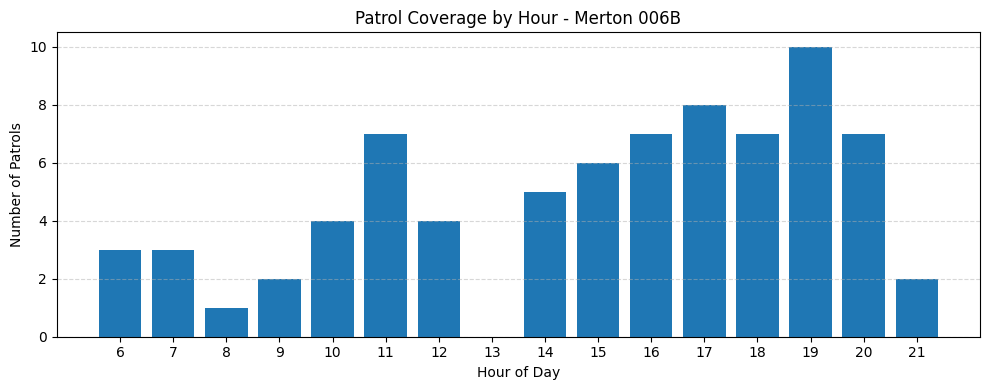

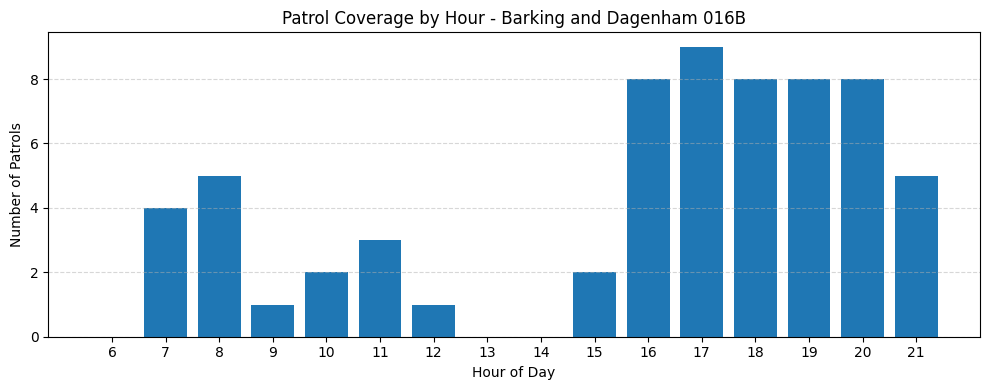

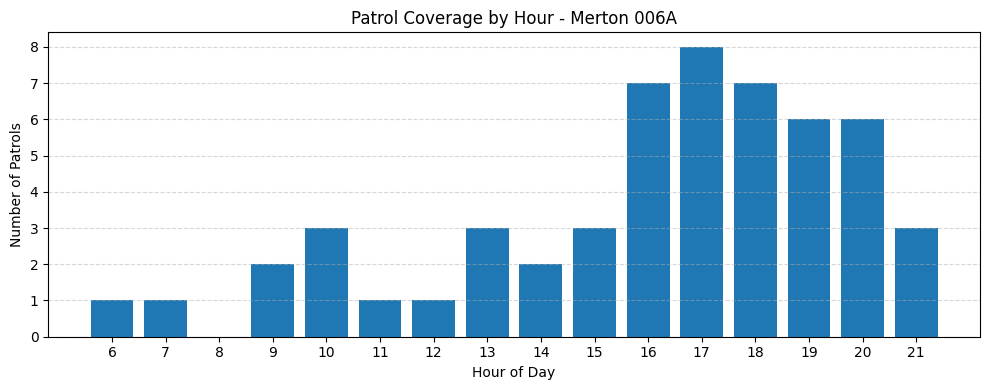

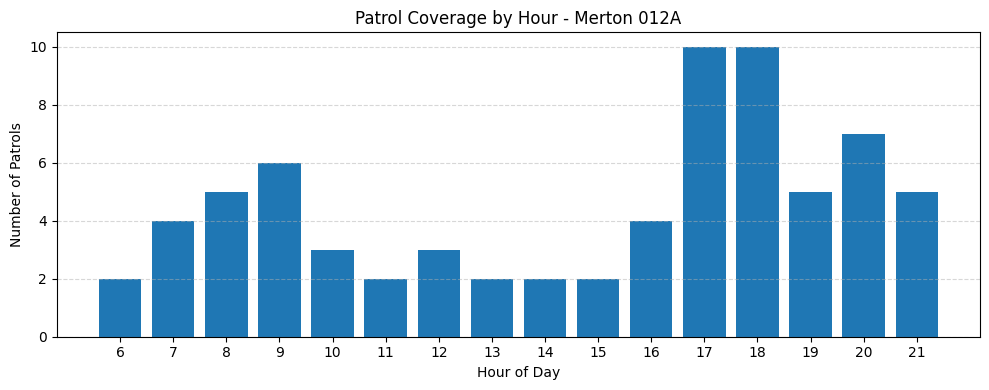

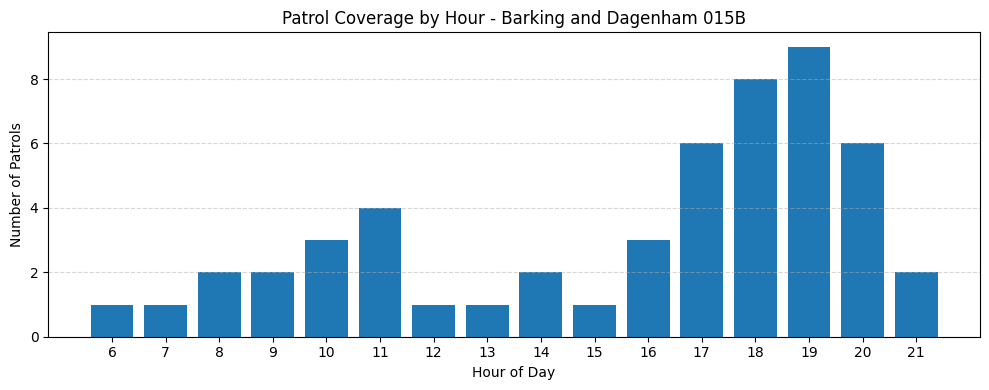

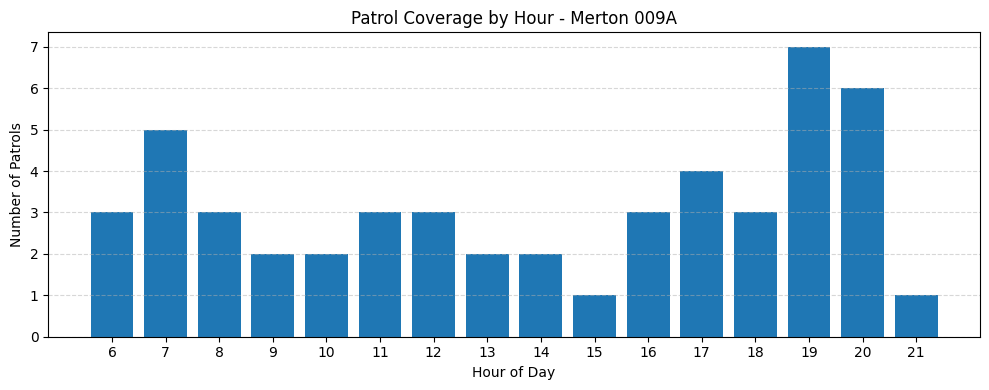

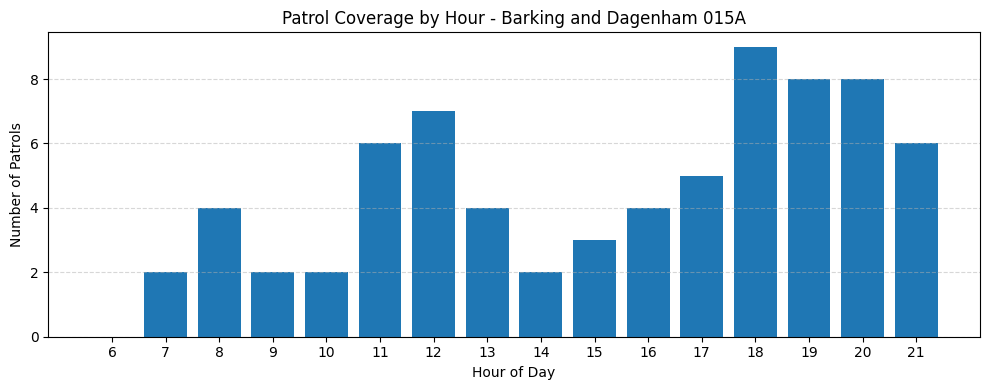

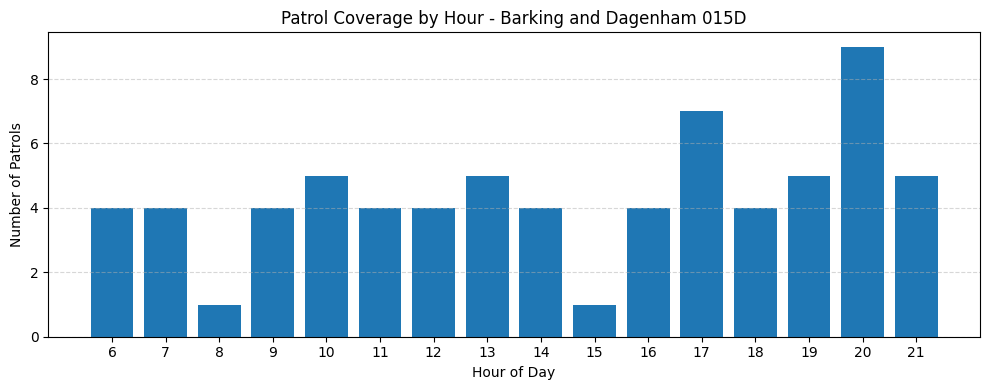

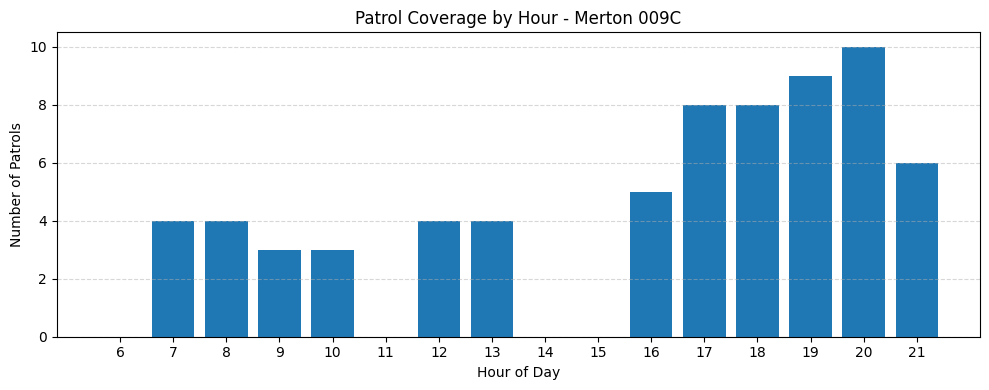

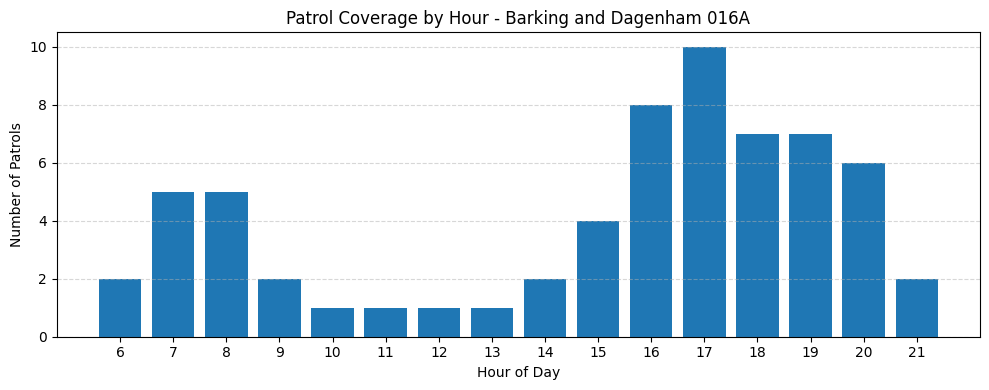

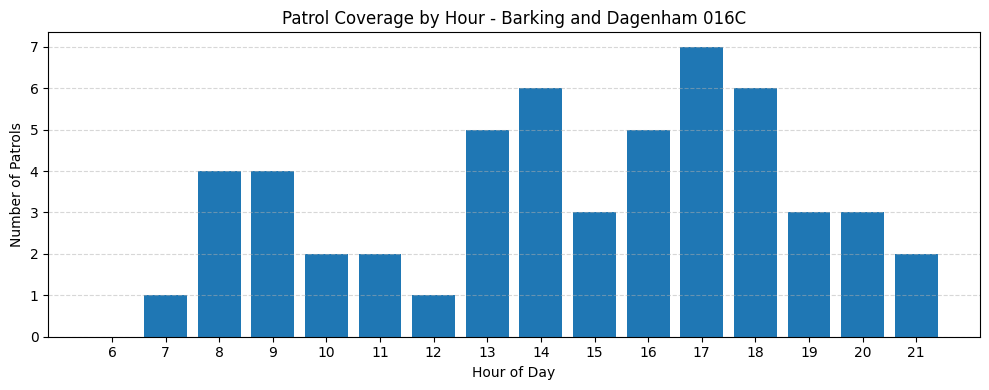

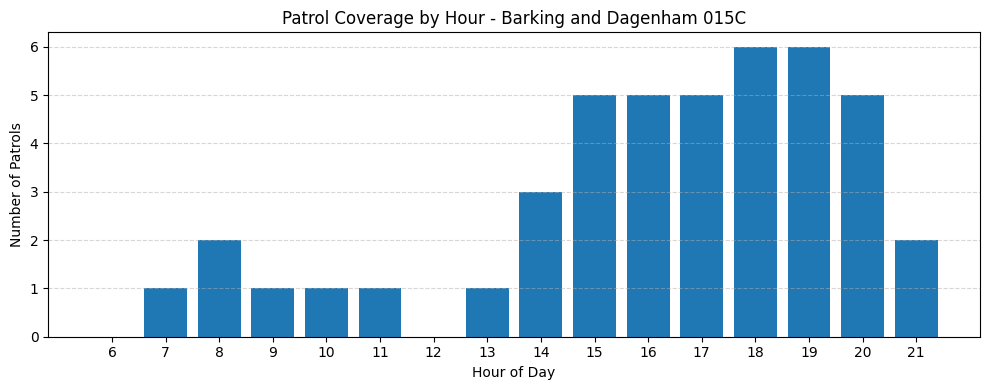

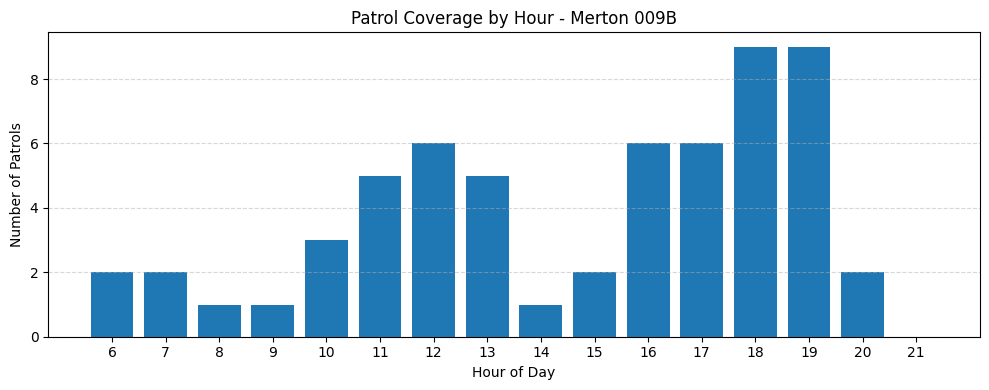

In [66]:
#1st check which hrs are patrolled
lsoa_patrols = {}

for _, row in schedule_df.iterrows():
    for cell in row[1:]:
        if pd.isna(cell):
            continue
        try:
            parts = cell.split('|')
            if len(parts) != 2:
                continue
            time_str = parts[0].strip()
            start_hour = int(time_str.split(':')[0])
            lsoa = parts[1].strip()
            hours = [start_hour, start_hour + 1]

            if lsoa not in lsoa_patrols:
                lsoa_patrols[lsoa] = {h: 0 for h in range(6, 22)}

            for h in hours:
                if h in lsoa_patrols[lsoa]:
                    lsoa_patrols[lsoa][h] += 1
        except Exception as e:
            print(f"Skipping entry '{cell}' due to error: {e}")

# Plot em
for lsoa, hourly_counts in lsoa_patrols.items():
    plt.figure(figsize=(10, 4))
    plt.bar(hourly_counts.keys(), hourly_counts.values())
    plt.title(f"Patrol Coverage by Hour - {lsoa}")
    plt.xlabel("Hour of Day")
    plt.ylabel("Number of Patrols")
    plt.xticks(range(6, 22))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()



In [79]:
#more schedule analysis
#check popo hrs
# weeks in the month
week_ranges = {
    "Week 1": [f"Day {i}" for i in range(1, 8)],
    "Week 2": [f"Day {i}" for i in range(8, 15)],
    "Week 3": [f"Day {i}" for i in range(15, 22)],
    "Week 4": [f"Day {i}" for i in range(22, 29)],
}

violations = []
for idx, row in schedule_df.iterrows():
    officer_id = row['Officer ID']
    for week_name, days in week_ranges.items():
        # Count only if the cell is not empty or purely whitespace
        patrol_days = sum(
            pd.notna(row[day]) and str(row[day]).strip() != '' for day in days
        )
        if patrol_days > 4:
            violations.append((officer_id, week_name, patrol_days))
print(violations)

for officer_id, week_name, count in violations:
    print(f"Officer {officer_id} works {count} days in {week_name} (limit is 4)")

# now getting all popo patrol hrs
day_columns = [col for col in schedule_df.columns if col.startswith("Day ")]

# Each entry is a 2-hour shift
total_shifts = sum(
    schedule_df[day].apply(lambda x: pd.notna(x) and str(x).strip() != '').sum()
    for day in day_columns
)

# total hours
total_hours_worked = total_shifts * 2

print(f"Total number of shifts: {total_shifts}")
print(f"Total patrol hours: {total_hours_worked}")

# # of shifts per officer
day_columns = [col for col in schedule_df.columns if col.startswith("Day ")]

# shifts per officer
schedule_df["Shifts Worked"] = schedule_df[day_columns].apply(
    lambda row: row.apply(lambda x: pd.notna(x) and str(x).strip() != '').sum(), axis=1
)

officer_shifts = schedule_df[["Officer ID", "Shifts Worked"]]



[]
Total number of shifts: 400
Total patrol hours: 800
           Officer ID  Shifts Worked
0     Abbey_Officer_1              4
1     Abbey_Officer_2              4
2     Abbey_Officer_3              4
3     Abbey_Officer_4              4
4     Abbey_Officer_5              4
..                ...            ...
95   Abbey_Officer_96              4
96   Abbey_Officer_97              4
97   Abbey_Officer_98              4
98   Abbey_Officer_99              4
99  Abbey_Officer_100              4

[100 rows x 2 columns]


In [80]:
officer_shifts.head(100)

,Officer ID,Shifts Worked
0,Abbey_Officer_1,4
1,Abbey_Officer_2,4
2,Abbey_Officer_3,4
3,Abbey_Officer_4,4
4,Abbey_Officer_5,4
...,...,...
95,Abbey_Officer_96,4
96,Abbey_Officer_97,4
97,Abbey_Officer_98,4
98,Abbey_Officer_99,4


There are 4 LSOAs that don't really fit that well into wards:

Hillingdon 015F
- fits into wards Uxbridge North (74%) and Uxbridge South
Hackney 002F
- fits into wards Brownswood (66%)
Southwark 022F
-  fits into wards Peckham (64%)
Southwark 009F
- fits into wards East Walworth (57%)

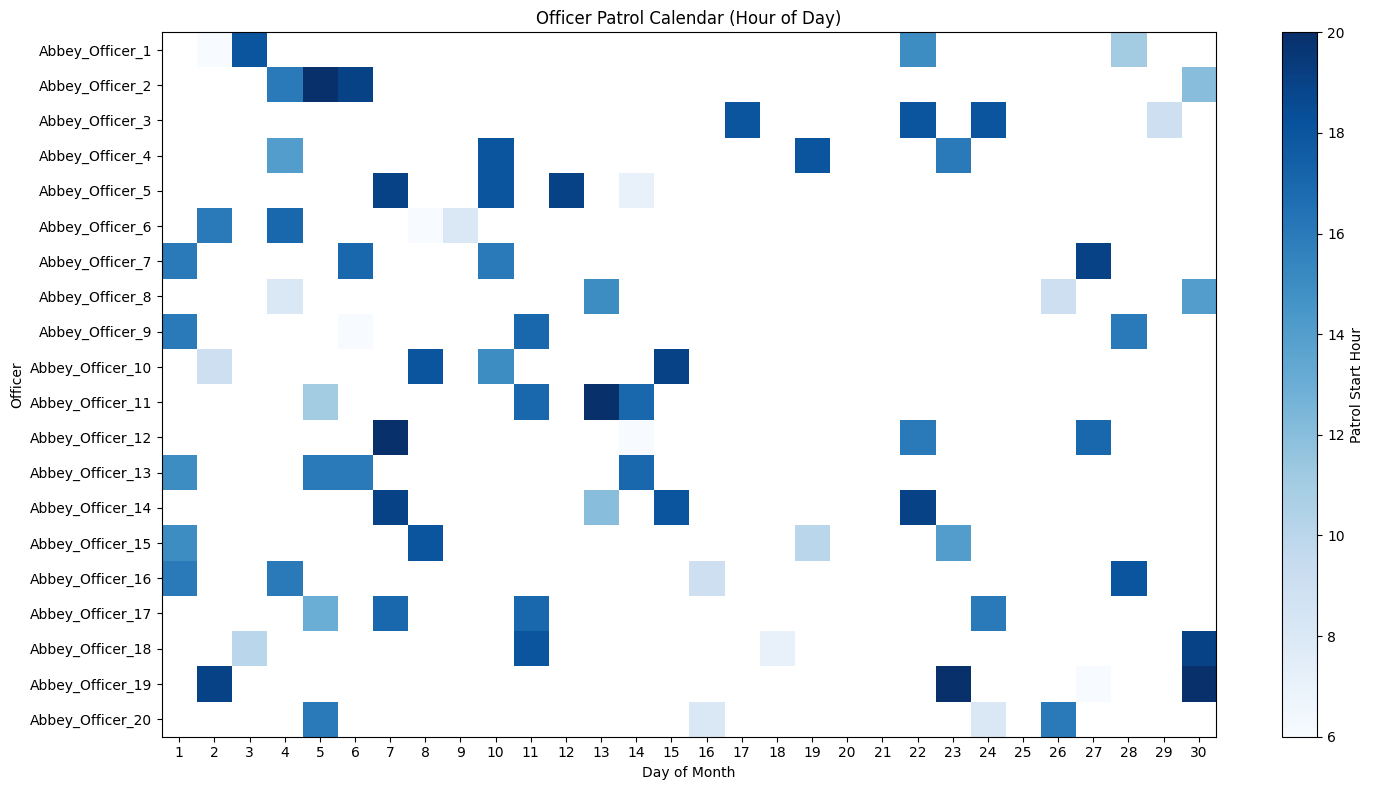

In [83]:
overview = schedule_df.copy()
day_cols = [col for col in overview.columns if col.startswith("Day")]

for col in day_cols:
    overview[col] = overview[col].apply(
        lambda x: int(x.split(":")[0]) if isinstance(x, str) and x.strip() != '' else np.nan
    )


fig, ax = plt.subplots(figsize=(15, 8))

# subset
subset = overview.head(20).set_index("Officer ID")

cax = ax.imshow(subset[day_cols], cmap="Blues", aspect="auto", interpolation="none")

ax.set_title("Officer Patrol Calendar (Hour of Day)")
ax.set_xlabel("Day of Month")
ax.set_ylabel("Officer")


ax.set_xticks(np.arange(len(day_cols)))
ax.set_xticklabels([col.replace("Day ", "") for col in day_cols])

ax.set_yticks(np.arange(len(subset)))
ax.set_yticklabels(subset.index)

# colorbar
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label("Patrol Start Hour")

plt.tight_layout()
plt.show()

